# Изучение рынка заведений общественного питания Москвы

- Автор: Овчинникова Марина
- Дата: 23.03.2025

## Цели и задачи проекта

**Цель:** Провести исследовательский анализ данных рынка заведений общественного питания Москвы для определения наиболее удачного сегмента для открытия нового заведения.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных и ответьте на вопросы:

- Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.
- Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.
- Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.
- Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.
- Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?
- Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.
- Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.
- Изучите вариацию среднего чека заведения (столбец middle_avg_bill) в зависимости от района Москвы. Проанализируйте цены в центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.

4. Сформулировать выводы по проведенному анализу.

## Описание данных

Для анализа поступили данные заведений общественного питания Москвы. 
Данные состоят из двух датасетов:

- `datasets/rest_info.csv` - информация о заведениях общественного питания;
- `datasets/rest_price.csv` - информация о среднем чеке в заведениях общественного питания

### Описание датасета `datasets/rest_info.csv`
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки);
- `seats` — количество посадочных мест.

### Описание датасета `/datasets/rest_price.csv`
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например: «Средний счёт: 1000–1500 ₽»; «Цена чашки капучино: 130–220 ₽»; «Цена бокала пива: 400–600 ₽» и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»: Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений. Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число. Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»: Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений. Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число. Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

# Содержимое проекта

- [1. Загрузка данных и знакомство с ними](#1.-Загрузка-данных-и-знакомство-с-ними)
- [2. Предобработка данных](#2.-Предобработка-данных)
- [3. Исследовательский анализ данных](#3.-Исследовательский-анализ-данных)
- [4. Итоговый вывод и рекомендации](#4.-Итоговый-вывод-и-рекомендации)


# 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
try:
    import phik
except ImportError:
    import phik
!pip install phik
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix


In [2]:
# Выгружаем данные в переменные rest_info и rest_price:
rest_info =pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета rest_info.csv:

In [3]:
# Выводим первые строки датафрейма на экран
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет rest_info.csv содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов приведены к одному виду и не требуют преобразований
- Представленные данные содержат строковые и числовые значения и хранятся в типах данных object, int64 или float64.  Значения в столбце chain типа int64 показывают, является ли заведение сетевым, и содержат значения 1 или 0 — размерность этих данных можно оптимизировать. Значения в столбце seats типа float64 показывают количество посадочных мест и могли бы быть преведены к целочисленному типу данных, если бы не содержали пропуски.
- В столбцах hours и seats содержаться пропуски. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Значения в столбцах соответствуют своему описанию.

Познакомимся с данными датасета rest_price.csv^:

In [5]:
# Выводим первые строки датафрейма на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет rest_price.csv содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов приведены к одному виду snake case и не требуют преобразований
- Представленные данные содержат строковые и числовые значения и хранятся в типах данных object или float64. 
- Во всех столбцах, кроме id, встречаются пропуски. Наибольшее количество пропусков в столбце middle_coffee_cup, однако данные этого столбца не будут использоваться в анализе данных.
- Значения в столбцах соответствуют своему описанию.

---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Представленные данные включают два датасета, содежащих 9 столбцов/ 8406 строк и 5 столбцов/ 4058 строк данных.

Первичное знакомство показывает, что данные соответствуют описанию. 

В обоих датасетах содержатся пропущенные значения, однако количество пропущенных значений в датасете, содержащем информацию о среднем чеке в заведениях общественного питания Москвы, значительно больше.

Названия столбцов корректны и не требует правок. В целом в датасетах используются верные типы данных, однако размерность данных в столбце chain типа int64 можно оптимизировать.

### Подготовка единого датафрейма

Задача проекта предполагает изучить рынок заведений общественного питания Москвы, а также вариацию среднего чека заведения в зависимости от района Москвы. Поэтому необходимо соединить данные о самих заведениях rest_info.csv и среднем чеке в них rest_price.csv.

Соединим данные по типу 'left', сделав основным датасет rest_info.csv и дополнив его информацией о среднем чеке из датасета rest_price.csv. Соединять данные будем по id заведения: 


In [7]:
# Соединяем данные в единый датафрейм df
df = rest_info.merge(rest_price, how='left', on='id')

In [8]:
# Выводим первые строки объединенного датафрейма на экран
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


# 2. Предобработка данных



Изучим типы данных датафрейма:

In [10]:
# Проверим оптимизацию
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Т.к. данные стобца chain показывают наличие признака "сетевое/несетевое" у заведения и содержат значения 1 или 0, то размерность этих данных можно понизить.

In [11]:
# Оптимизируем целочисленный тип данных для столбца chain
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

Посчитаем абсолютное и относительное количество пропущенных значений в каждом столбце:

In [12]:
# Применяем метод isna() к датафрейму df
df.isna().sum().sort_values()

id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
hours                 536
seats                3611
avg_bill             4590
price                5091
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [13]:
# Посчитаем доли строк с пропусками
df.isna().mean().sort_values()

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
rating               0.000000
chain                0.000000
hours                0.063764
seats                0.429574
avg_bill             0.546039
price                0.605639
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

Процент пропусков в столбце hours не большой. Т.к. данные из этого столбца будут использоваться для отнесения заведения к категории круглосуточного или нет, то лучше удалить эти строки.

Процент пропусков в столбцах seats, price, avg_bill, middle_avg_bill, middle_coffee_cup слишком большой для удаления этих строк или замены на какое-либо определенное значение, т.к это окажет большое влияние на итоговый результат.

In [14]:
df = df.dropna(subset=['hours']) 

In [15]:
df.isna().sum().sort_values()

id                      0
name                    0
category                0
address                 0
district                0
hours                   0
rating                  0
chain                   0
seats                3375
avg_bill             4062
price                4560
middle_avg_bill      4727
middle_coffee_cup    7336
dtype: int64

Проверим датафрейм на явные дубликаты

In [16]:
# Посчитаем количество явных дубликатов в датафрейме df
df.duplicated().sum()

0

Датафрейм не содержит явных дубликатов.

Проверим датафрейм на неявные дубликаты. Изучим значения некоторых полей (id, price, category, district, name, address), проведем нормализацию, чтобы убедиться, что там нет неявных дубликатов.

In [17]:
# Посчитаем количество неявных дубликатов в датафрейме df по столбцу id (все значения должны быть уникальными)
df.duplicated(subset='id').sum()

0

In [18]:
# Проверим уникальность значений в столбцах price, category, district и chain
print(df['price'].unique())
print(df['category'].unique())
print(df['district'].unique())
print(df['chain'].unique())
print(df['hours'].unique())

[nan 'выше среднего' 'средние' 'высокие' 'низкие']
['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая']
['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ']
[0 1]
['ежедневно, 10:00–22:00'
 'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00'
 'ежедневно, 09:00–22:00' ... 'пн-пт 08:30–21:30; сб,вс 09:00–21:30'
 'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00'
 'пн-сб 10:30–21:30']


Среди значений в столбцах price, category, district, chain и hours нет неявных дубликатов. Преобразований не требуется.

In [19]:
# Проверим уникальность значений в столбце name
for name in df['name'].unique():
    print(name)

WoWфли
Четыре комнаты
Хазри
Dormouse Coffee Shop
Иль Марко
Sergio Pizza
Огни города
Mr. Уголёк
Donna Maria
Готика
Great Room Bar
Шашлык Шефф
Заправка
Буханка
У Сильвы
Дом обеда
База Стритфуд
Чайхана Беш-Бармак
Час-Пик
Пекарня
Чебуреки Манты
7/12
Крымские чебуреки
Drive Café
В парке вкуснее
Пикочино
Шаурму Х@чу
Mafe
Кушай Город
Кафедра
Алталия
Додо Пицца
Изба
Домино'с Пицца
Виладж пицца
Пекарня № 1 Грузинская кухня
Халяль закусочная
Шаурмагия
Крошка Картошка
Варня кафе
Суши & пицца
9 Bar Coffee
CofeFest
Кафе
БлинБери
2U-Ту-Ю
Шаурма
Арамье
Cofix
Royal Coffee
Шашлык
Чебуреки и манты
Мир пиццы
Coffeekaldi's
Хинкали Gали!
Чебуречная история
Кафе Лоза
Пить Есть!
Pizza Hut
Testo мания
Альбатрос
Молинари
Штаб квартира
Мимино
Алазанская долина
Гуава бар
Лакрица
Веранда
Хинкали-Gали!
Ресторан Купец
Оазис
Ресторан Самарканд
Ресторан Landau Cafe & Grill Bar
Му-Му
Coffee Way
Пиросмани
Аль-Бухари
Meat Doner Kebab
Дежене
Халяль
Гриль Хаус
Zамания
Сахарочек
Кафе на Пришвина
ЛавашОК
Jamamai asian kitch

Количество уникальных значений названий ресторанов (так же, как и адресов) слишком большое для визуальной оценки. Попробуем посчитать количество неявных дубликатов, нормируем данные в этих столбцах и еще раз проверим дубликаты.

In [20]:
# Посчитаем количество неявных дубликатов в датафрейме df по столбцу name
df.duplicated(subset='name').sum()

2557

Уменьшим количество неявных дубликатов в столбце name. Приведем названия к нижнему регистру и внесем корректироки по тем ошибкам ввода, которые удалось обнаружить:

In [21]:
# Приведем названия заведений к нижнему регистру и снова посчитаем количество неявных дубликатов
df['name'] = df['name'].str.lower()
df.duplicated(subset='name').sum()

2651

In [22]:
# Сделаем некоторые преобразования данных для уменьшения количества невяных дубликатов в значениях столбца name
# В названиях встречается ошибка ввода подобного рода 'Corner cafe & kitchen' и 'Corner cafe&kitchen'. Добавим пробелы до и после знака & и удалим получившиеся двойные
df['name'] = df['name'].str.replace('&',' & ')
df['name'] = df['name'].str.replace('  ',' ')
df['name'] = df['name'].str.replace('9 Bar Coffe','9 Bar Coffee')
df['name'] = df['name'].str.replace('MainFood','Main Food')
df.duplicated(subset='name').sum()

2655

Количество неявных дубликатов по названию больше, что по сочетанию названия и категории заведения. Это означает, что заведения с одним и тем же названием (предположительно сетевые) могут относиться к разным категориям заведений. 
Следует уточнить у заказчика/предоставителя данных возможно ли такое для сетевых заведений и исходя из ответа принимать решение о действиях с такого родя дубликатов (оставлять их или менять категорию).
В данном случае оставим как есть.

In [23]:
# Посчитаем количество неявных дубликатов в датафрейме df по столбцу address
df.duplicated(subset='address').sum()

2410

In [24]:
# Приведем адреса к нижнему регистру и снова посчитаем количество неявных дубликатов
df['address'] = df['address'].str.lower()
df.duplicated(subset='address').sum()

2411

Сократили количество неявных дубликатов значений, после приведения значений в столбцах name и address к нижнему регистру. 

In [25]:
# Проверим неявные дубликаты по столбцам 'name', 'address'
df.duplicated(subset=['name', 'address']).sum() 

3

Найдены три строки с неявными дубликатами по столбцам 'name', 'address'. Выведем их и убедимся:

In [26]:
df[df.duplicated(['name', 'address'],keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN


Количество неявных дубликатов незначительно. Такие дубликаты могут быть связано с тем, что мы работаем с данными из разных источников - Яндекс Карты и Яндекс Бизнес и информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках.

Первое заведение с названием "кафе" имеет отличные часы работы. В анализе важно, является ли заведение круглосуточным, оба варианта графика работы не являются круглосуточными.

Второе заведение с названием "more poke" имеет отличие по графику работы, а также по отнесению к сетевому и несетевому заведению. Согласно общедоступным данным "more poke" - это сетевое заведение.

Третье заведение с названием "раковарня клешни и хвосты" имеет отличие по графику работы, а также по отнесению к сетевому и несетевому заведению. Согласно общедоступным данным "раковарня клешни и хвосты" - это сетевой ресторан.

In [27]:
# Удалим найденные дубликаты, оставив последнюю запись
df = df.drop_duplicates(subset=['name', 'address'], keep='last', inplace=False) 

In [28]:
# Проверим
df.duplicated(subset=['name', 'address']).sum() 

0

In [29]:
# Посмотрим на полученный после предобработки датафрейм
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7867 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7867 non-null   object 
 1   name               7867 non-null   object 
 2   category           7867 non-null   object 
 3   address            7867 non-null   object 
 4   district           7867 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             7867 non-null   float64
 7   chain              7867 non-null   int8   
 8   seats              4493 non-null   float64
 9   price              3310 non-null   object 
 10  avg_bill           3808 non-null   object 
 11  middle_avg_bill    3143 non-null   float64
 12  middle_coffee_cup  534 non-null    float64
dtypes: float64(4), int8(1), object(8)
memory usage: 806.7+ KB


In [30]:
(8406-7867)/8406*100

6.412086604806092

В ходе предобработки датафрейма мы потеряли 6.4% данным. Выборка не потеряла свою репрезентативность.

Создадим столбец is_24_7 с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
логическое значение True — если заведение работает ежедневно и круглосуточно;
логическое значение False — в противоположном случае.

In [31]:
# Создадим столбец is_24_7 
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

In [32]:
# Убедимся, что столбец создан
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


---

### Промежуточный вывод


В результате предобработки данных были выполнены следующие действия:

- Понизили размерность данных в столбце chain.
- Изучены пропуски в данных. Пропуски в столбце hours были удалены, пропуски в столбцах seats, price, avg_bill, middle_avg_bill, middle_coffee_cup оставлены без изменений, т.к. их количество слишком велико для удаления этих строк или замены на какое-либо определенное значение.
- Данные проверили на явные дубликаты — в данных их нет. 
- Данные проверили на неявные дубликаты. Снизили их количество нормализуя значения в столбцах name и address.

## 3. Исследовательский анализ данных


---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

Исследуем категории заведений и количество объектов общественного питания по каждой категории:

In [33]:
# Проверяем распределение данных по значениям в столбце category в относительных значениях
print('Распределение заведений по категориям:')
print(df['category'].value_counts(normalize=True))

Распределение заведений по категориям:
кафе               0.254481
ресторан           0.250032
кофейня            0.177704
бар,паб            0.094954
пиццерия           0.079827
быстрое питание    0.072455
столовая           0.038897
булочная           0.031651
Name: category, dtype: float64


In [34]:
df_category=pd.concat([df['category'].value_counts(),
                      df['category'].value_counts(normalize=True)],
                     axis=1,
                     keys=('count','perc'))
print('Распределение заведений по категориям:')
print(df_category)

Распределение заведений по категориям:
                 count      perc
кафе              2002  0.254481
ресторан          1967  0.250032
кофейня           1398  0.177704
бар,паб            747  0.094954
пиццерия           628  0.079827
быстрое питание    570  0.072455
столовая           306  0.038897
булочная           249  0.031651


In [35]:
# код ревьюера
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

total_count = df.shape[0]
category_counts['share'] = category_counts['count'] / total_count

print(category_counts)

          category  count     share
0             кафе   2002  0.254481
1         ресторан   1967  0.250032
2          кофейня   1398  0.177704
3          бар,паб    747  0.094954
4         пиццерия    628  0.079827
5  быстрое питание    570  0.072455
6         столовая    306  0.038897
7         булочная    249  0.031651


В имеющихся данных представлены заведения 8-ми категорий:
- кафе;
- ресторан;
- кофейня;
- бар,паб;
- пиццерия;
- быстрое питание;
- столовая;
- булочная

50% анализируемых заведений относятся к двум категориям: "кафе" и "ресторан".


Для отображения информации о категориях заведений и количестве заведений общественного питания по каждой категории построим горизонтальную столбчатую диаграмму.

Визуализируем данные:

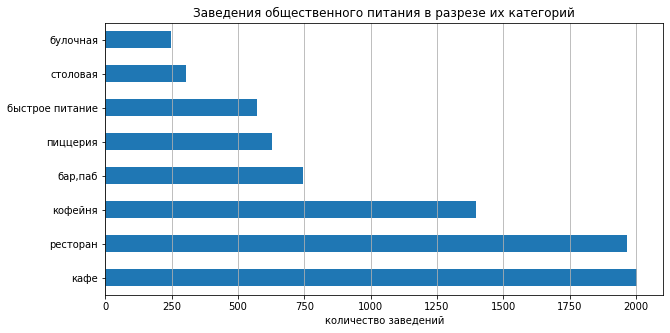

In [36]:
# Построим визуализацию
plt.figure(figsize=(10, 5))
df['category'].value_counts().plot(kind='barh', title='Заведения общественного питания в разрезе их категорий', rot=0)
plt.xlabel('количество заведений')
plt.grid(axis='x')
plt.show()

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

Исследуем распределение количества заведений по административным районам Москвы:

In [37]:
# Проверяем распределение заведений по административным районам Москвы в абсолютных значениях
print('Распределение заведений по административным районам Москвы:')
print(df['district'].value_counts())

Распределение заведений по административным районам Москвы:
Центральный административный округ         2211
Северный административный округ             844
Северо-Восточный административный округ     829
Южный административный округ                827
Западный административный округ             785
Восточный административный округ            723
Юго-Западный административный округ         650
Юго-Восточный административный округ        629
Северо-Западный административный округ      369
Name: district, dtype: int64


In [38]:
# Проверяем распределение заведений по административным районам Москвы в относительных значениях
print('Распределение заведений по административным районам Москвы:')
print(df['district'].value_counts(normalize=True))

Распределение заведений по административным районам Москвы:
Центральный административный округ         0.281047
Северный административный округ            0.107284
Северо-Восточный административный округ    0.105377
Южный административный округ               0.105123
Западный административный округ            0.099784
Восточный административный округ           0.091903
Юго-Западный административный округ        0.082624
Юго-Восточный административный округ       0.079954
Северо-Западный административный округ     0.046905
Name: district, dtype: float64


В данных присутствуют 9 административных районом Москвы. 28% анализируемых заведений расположены в Центральном административном округе Москвы. 

Визуализируем данные:

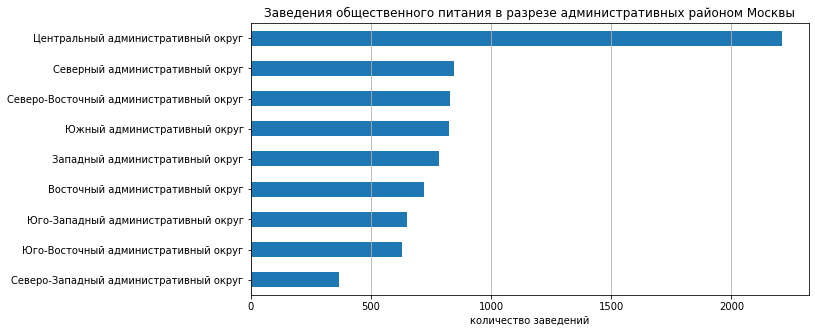

In [39]:
# Построим визуализацию
plt.figure(figsize=(10, 5))
df['district'].value_counts().sort_values().plot(kind='barh', title='Заведения общественного питания в разрезе административных районом Москвы', rot=0)
plt.xlabel('количество заведений')
plt.grid(axis='x')
plt.show()

Исследуем распределение заведений каждой категории в Центральном административном округе Москвы: 

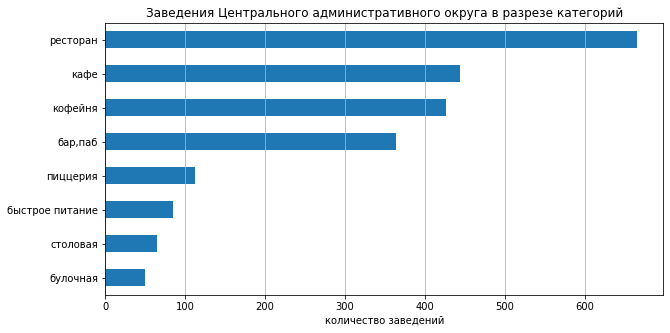

In [40]:
# Сделаем срез заведений, относящихся к Центральному администритивному округу, и изучим заведения в разрезе категорий
plt.figure(figsize=(10, 5))
cent_df=df[df['district']=='Центральный административный округ']
cent_df['category'].value_counts().sort_values().plot(kind='barh', title='Заведения Центрального административного округа в разрезе категорий', rot=0)
plt.xlabel('количество заведений')
plt.grid(axis='x')
plt.show()

Большинство заведений Центрального административного округа Москвы относятся к категории "ресторан" (около 650), далее - "кафе" и "кофейня" (около 400 в каждой категории).

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

Изучим соотношение сетевых и несетевых заведений в целом по всем данным:

In [41]:
# Проверяем распределение заведений по признаку сетевое/несетевое в абсолютных значениях
print('Количество сетевых и несетевых заведений Москвы:')
print(df['chain'].value_counts())

Количество сетевых и несетевых заведений Москвы:
0    4778
1    3089
Name: chain, dtype: int64


In [42]:
# Проверяем распределение заведений по признаку сетевое/несетевое в относительных значениях
print('Количество сетевых и несетевых заведений Москвы:')
print(df['chain'].value_counts(normalize=True))

Количество сетевых и несетевых заведений Москвы:
0    0.607347
1    0.392653
Name: chain, dtype: float64


Среди анализируемых заведений больше несетевых. Соотношение несетевых и сетевых составляет 61% и 39% соответственно.

Визуализируем данные:

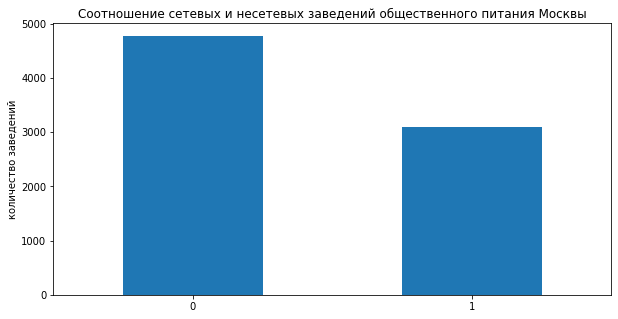

In [43]:
# Построим визуализацию
plt.figure(figsize=(10, 5))
df['chain'].value_counts().plot(kind='bar', title='Соотношение сетевых и несетевых заведений общественного питания Москвы', rot=0)
plt.ylabel('количество заведений')
plt.show()

Изучим соотношение сетевых и несетевых заведений в разрезе категорий заведения:

In [44]:
# Проверяем распределение заведений по признаку сетевое/несетевое в абсолютных значениях
print('Количество сетевых и несетевых заведений Москвы:')
print(df.groupby('category')['chain'].value_counts(normalize=True))

Количество сетевых и несетевых заведений Москвы:
category         chain
бар,паб          0        0.787149
                 1        0.212851
булочная         1        0.618474
                 0        0.381526
быстрое питание  0        0.607018
                 1        0.392982
кафе             0        0.644855
                 1        0.355145
кофейня          1        0.510730
                 0        0.489270
пиццерия         1        0.525478
                 0        0.474522
ресторан         0        0.638027
                 1        0.361973
столовая         0        0.722222
                 1        0.277778
Name: chain, dtype: float64


Сетевыми заведениями чаще являются булочные (62%), пиццерии (53%) и кофейни (51%). Среди других категорий заведений процент сетевых составляет является менее 50%.

Визуализируем данные:

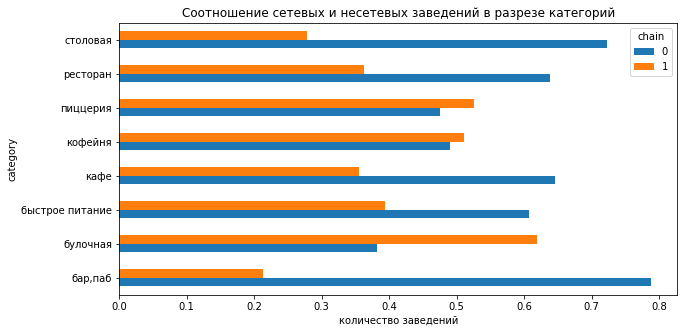

In [45]:
# Построим визуализацию
df_unstack = df.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0)
df_unstack.plot(kind='barh', title='Соотношение сетевых и несетевых заведений в разрезе категорий', rot=0,figsize=(10, 5))
plt.xlabel('количество заведений')
plt.show()

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


Исследуем количество посадочных мест в заведениях:

In [46]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4493.000000
mean      107.818607
std       119.221227
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [47]:
# Изучим несколько заведения с количеством мест 0 и больше 1000
min_seats_df=df.sort_values('seats')
min_seats_df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
7340,db471b750a6a47e9be6480cf8f172b3e,take and wake,кофейня,"москва, поречная улица, 10",Юго-Восточный административный округ,"ежедневно, 10:00–22:00",4.2,1,0.0,NaN,Цена чашки капучино:100–160 ₽,NaN,130.0,False
2986,6fbf4029abfc4d60baacb90214ea8145,шаурма,кафе,"москва, бульвар маршала рокоссовского, 31",Восточный административный округ,"ежедневно, 10:00–00:00",3.9,0,0.0,NaN,NaN,NaN,NaN,False
2973,69be7faa6f43499e89b817567ae61af7,шаурма,кафе,"москва, бульвар маршала рокоссовского, 36/1",Восточный административный округ,"ежедневно, 08:00–22:00",3.8,0,0.0,NaN,NaN,NaN,NaN,False
2906,b1ad1e0c70204b24ac8724b14119a6d0,кофе с собой,кафе,"москва, сиреневый бульвар, 64а",Восточный административный округ,"ежедневно, круглосуточно",3.5,1,0.0,NaN,Средний счёт:90–450 ₽,270.0,NaN,True
7259,669bc28d6683401ba43dc6078f6f970a,пицца паоло,пиццерия,"москва, коломенская улица, 19, корп. 2",Южный административный округ,вт-вс 10:30–22:00,3.7,1,0.0,средние,Средний счёт:300–500 ₽,400.0,NaN,False


In [48]:
max_seats_df=df[df['seats']>1000]
max_seats_df.tail()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
6641,0508ba663a4c42d1b5068e51afcc26ef,one price coffee,кофейня,"москва, проспект вернадского, 84, стр. 1",Западный административный округ,"ежедневно, 08:30–20:00",4.3,1,1288.0,NaN,NaN,NaN,NaN,False
6658,19a223ff04f74af7a12bd87b77ce468b,гудбар,"бар,паб","москва, проспект вернадского, 97, корп. 1",Западный административный округ,"пн-пт 11:00–23:00; сб,вс 13:00–23:00",4.1,0,1288.0,средние,Средний счёт:700 ₽,700.0,NaN,False
6807,ba5a32dfee6c4661a25c0ea2d39f393d,loft-cafe академия,кафе,"москва, проспект вернадского, 84, стр. 1",Западный административный округ,пн-пт 09:00–20:00; сб 09:00–16:00,3.6,0,1288.0,NaN,NaN,NaN,NaN,False
6808,a555f30eac234e6ca28480afa418ed3c,яндекс лавка,ресторан,"москва, проспект вернадского, 51, стр. 1",Западный административный округ,"ежедневно, круглосуточно",4.0,1,1288.0,NaN,NaN,NaN,NaN,True
6838,0b8062d352c84a65bca70622eecbc745,alternative coffee,кофейня,"москва, проспект вернадского, 41, стр. 1",Западный административный округ,"пн-пт 09:00–21:00; сб,вс 09:00–22:00",4.3,0,1288.0,NaN,NaN,NaN,NaN,False


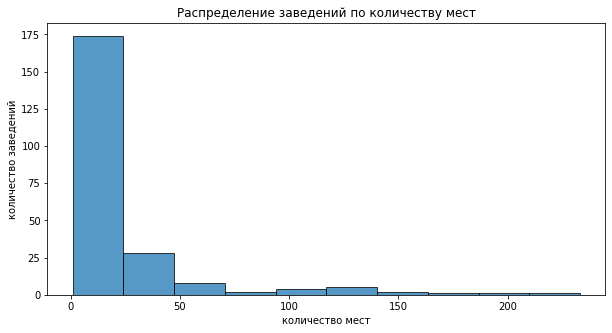

In [49]:
# Построим визуализацию
plt.figure(figsize=(10, 5))
df['seats'].value_counts().plot(
    kind='hist', 
    alpha=0.75,
    edgecolor='black',
    rot=0)
plt.title('Распределение заведений по количеству мест')
plt.xlabel('количество мест')
plt.ylabel('количество заведений')
plt.show()

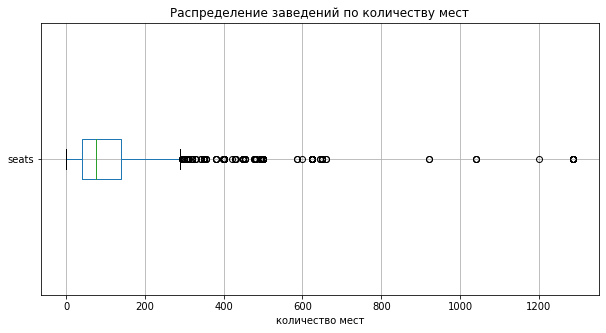

In [50]:
plt.figure(figsize=(10, 5))
df.boxplot(column='seats', vert=False)
plt.title('Распределение заведений по количеству мест')
plt.xlabel('количество мест')
plt.show()

На гистограмме видно, что распределение значений в столбце 'seats' является правоасимметричным, т.е. среди значений присуствуют значения сильно выше средних.
В данных встречаются как аномальные значения (0), так и выбросы (значения выше 300).
Присутствие заведений как с нулевым количеством посадочных мест, так и с количеством посадочных мест сильно выше среднего может быть связано с тем, что заведение работает на доставку и/или на вынос и информация об этом по-разному отображается в столбце 'seats'. 

Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест. 
Для этого посчитаем медиану по количеству посадочных мест, т.к. медиана более устойчива к выбросам:

In [51]:
df.groupby('category')['seats'].median().sort_values()

category
булочная           50.0
пиццерия           55.0
кафе               60.0
быстрое питание    69.5
столовая           73.5
кофейня            80.0
бар,паб            82.5
ресторан           86.0
Name: seats, dtype: float64

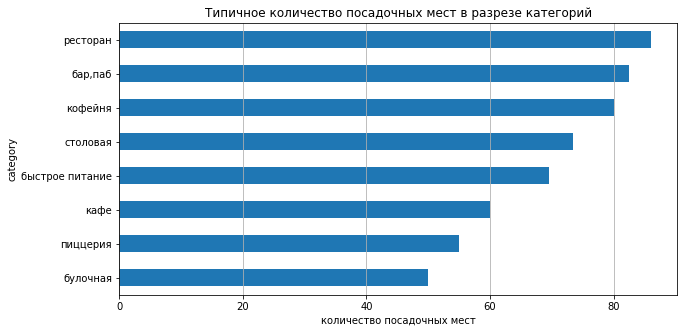

In [52]:
# Построим визуализацию
df.groupby('category')['seats'].median().sort_values().plot(kind='barh',rot=0,figsize=(10, 5))
plt.title('Типичное количество посадочных мест в разрезе категорий')
plt.xlabel('количество посадочных мест')
plt.grid(axis='x')
plt.show()

Наибольшее количество посадочных мест характерно для ресторанов, наименьшее - для булочных.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

Исследуем распределение значений в столбце rating:

In [53]:
# Посмотрим, какие данные представлены в столбце 'rating' для того, чтобы выявить аномальные значения
df['rating'].unique()

array([5. , 4.5, 4.6, 4.4, 4.7, 4.8, 4.3, 4.9, 4.2, 4.1, 4. , 3.8, 3.9,
       3.6, 2.8, 2.7, 3.7, 3.1, 2. , 1.4, 3.3, 3.5, 3.2, 2.9, 3.4, 2.3,
       2.2, 3. , 2.5, 2.6, 1.7, 1. , 1.1, 1.3, 2.1, 1.8, 1.9, 2.4, 1.6,
       1.5])

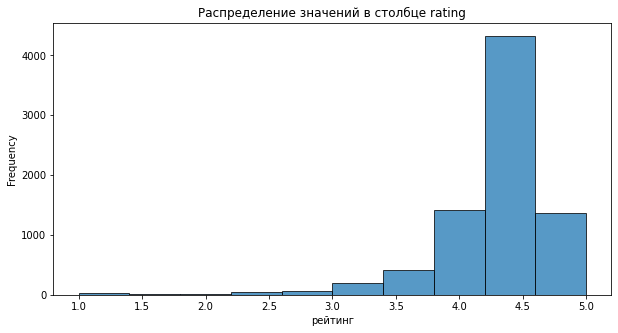

In [54]:
# Визуализируем распредление значений в столбце rating
plt.figure(figsize=(10, 5))
df['rating'].plot(
    kind='hist', 
    alpha=0.75,
    edgecolor='black',
    rot=0)
plt.title('Распределение значений в столбце rating')
plt.xlabel('рейтинг')
plt.show()

Изучим распределение средних рейтингов по категориям заведений:

In [55]:
# Рассчитаем средний рейтинг по категориях заведений
df.groupby('category')['rating'].mean().sort_values()

category
быстрое питание    4.058947
кафе               4.150799
столовая           4.217320
кофейня            4.275036
булочная           4.276707
ресторан           4.296136
пиццерия           4.301433
бар,паб            4.394511
Name: rating, dtype: float64

Визуализируем данные:

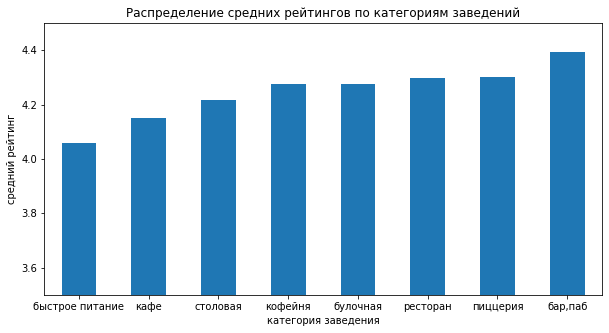

In [56]:
# Построим визуализацию
df.groupby('category')['rating'].mean().sort_values().plot(kind='bar',rot=0,figsize=(10, 5), ylabel='средний рейтинг', xlabel='категория заведения')
plt.title('Распределение средних рейтингов по категориям заведений')
plt.ylim(3.5, 4.5)
plt.show()

Усреднённые рейтинги для разных типов общепита различаются не сильно и находятся в пределах от 4.06 до 4.39

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений:

In [57]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['district', 'category', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.220942
district,0.197175
category,0.178342
is_24_7,0.174880
chain,0.114518
seats,0.000000


Визуализируем данные:

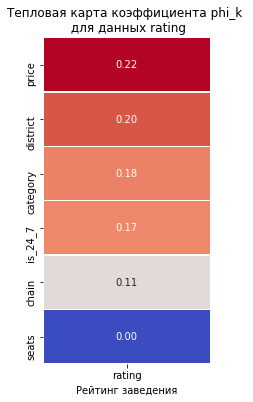

In [58]:
# Строим тепловую карту
plt.figure(figsize=(3, 6))
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False)
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведения')
plt.show()

Показатели корреляции находятся в диапазоне от 0 до 0.3, что говорит о том, что взаимосвязи практически нет. Среди полученных значений самое высокое между рейтингом и ценовой категорией заведения. 

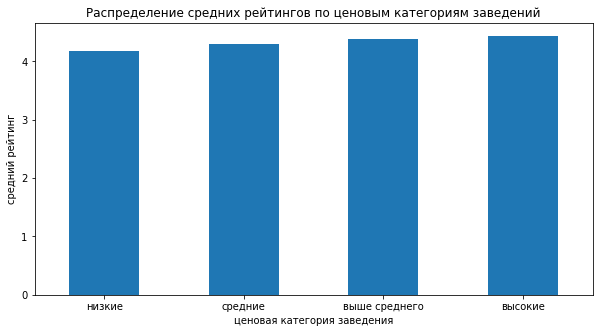

In [59]:
# Построим визуализацию
df.groupby('price')['rating'].mean().sort_values().plot(kind='bar',rot=0,figsize=(10, 5), ylabel='средний рейтинг', xlabel='ценовая категория заведения')
plt.title('Распределение средних рейтингов по ценовым категориям заведений')
plt.show()

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга:

In [60]:
top_15 = df.groupby(['name','category'])['rating'].agg(['count','mean']).sort_values('count',ascending=False)
print(top_15.head(15))

                                                     count      mean
name                                category                        
шоколадница                         кофейня            119  4.178151
кафе                                кафе                78  3.780769
домино'с пицца                      пиццерия            77  4.171429
додо пицца                          пиццерия            74  4.286486
one price coffee                    кофейня             72  4.069444
яндекс лавка                        ресторан            68  3.870588
cofix                               кофейня             65  4.075385
prime                               ресторан            49  4.114286
кофепорт                            кофейня             42  4.147619
кулинарная лавка братьев караваевых кафе                39  4.394872
теремок                             ресторан            36  4.105556
cofefest                            кофейня             31  3.977419
шаурма                            

Самым популярным заведением Москвы является кофейня "Шоколадница" со средним рейтингом 4,18.
В топ-15 популярных сетей Москвы входят заведения следующих категорий: кофейня (5 заведения), кафе (3), ресторан (3), пиццерия (2), быстрое питание (1) и булочная (1).

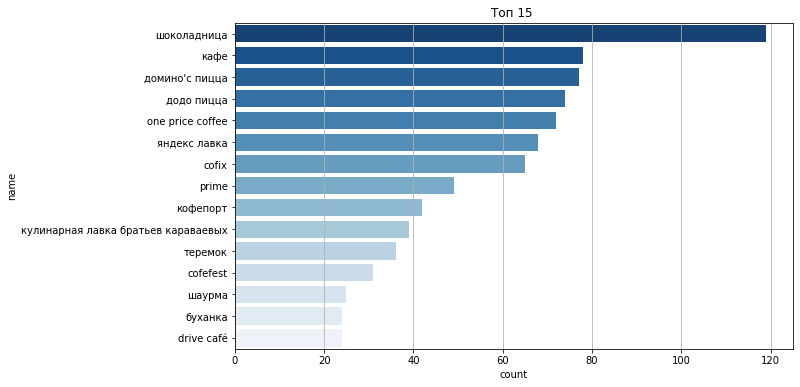

In [61]:
# Код ревьюера
top_15 = top_15.head(15).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_15, y='name', x='count', palette='Blues_r')
plt.title('Топ 15 ')
plt.grid(axis='x')
plt.show()

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


Изучим вариацию среднего чека заведения (столбец middle_avg_bill) в зависимости от района Москвы:

In [62]:
# Изучаем статистические показатели столбца middle_avg_bill
print('Средний чек в зависимости от района Москвы:')
df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)

Средний чек в зависимости от района Москвы:


district
Центральный административный округ         1190.559130
Западный административный округ            1053.072131
Северный административный округ             927.959627
Южный административный округ                836.301282
Северо-Западный административный округ      822.222930
Восточный административный округ            820.626923
Юго-Западный административный округ         792.561702
Северо-Восточный административный округ     716.611296
Юго-Восточный административный округ        654.097938
Name: middle_avg_bill, dtype: float64

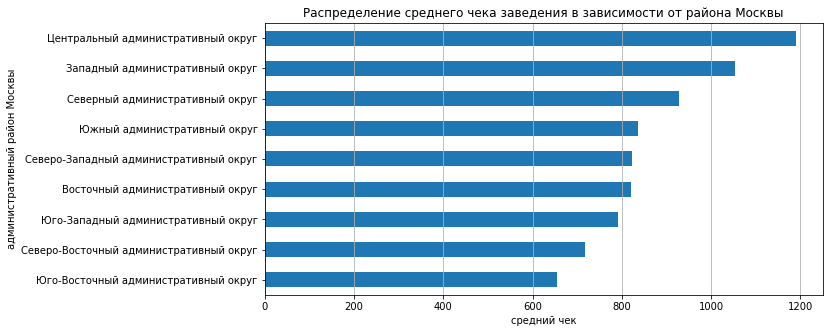

In [63]:
df.groupby('district')['middle_avg_bill'].mean().sort_values().plot(kind='barh',rot=0,figsize=(10, 5), xlabel='административный район Москвы')
plt.title('Распределение среднего чека заведения в зависимости от района Москвы')
plt.xlabel('средний чек')
plt.grid(axis='x')
plt.show()

Наибольший средний чек приходится на заведения Центрального административного округа (1190 руб.). Также высокий средний чек (больше 1000 руб.) в заведениях Западного административного округа. В целом, удалённость от центра приводит к уменьшению среднего чека, т.к. цен в заведениях. Самый низкий средний чек в заведениях Юго-Восточного административного округа.

---


---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

Исследовательский анализ данных показал:
1. В данных представлены заведения 8-ми категорий: кафе; ресторан; кофейня; бар,паб; пиццерия; быстрое питание; столовая; булочная. Наиболее часто встречаются заведения категорий "кафе","ресторан" и "кофейня". На их долю приходится 25%, 25% и 17% анализируемых заведений соответственно. Наименее часто - "столовая" и "булочная". На их долю приходится 4% и 3% заведений соответственно.
2. В данных присутствуют 9 административных районов Москвы: Центральный, Северный, Северо-Восточный, Южный, Западный, Восточный, Юго-Западный, Юго-Восточный и Северо-Западный. 28% анализируемых заведений расположены в Центральном административном округе Москвы. Большинство заведений Центрального административного округа Москвы относятся к категории "ресторан" (около 650), далее - "кафе" и "кофейня" (около 400 в каждой категории). 
3. Соотношение несетевых и сетевых заведений составляет 61% и 39% соответственно. Сетевыми заведениями чаще являются булочные (62%), пиццерии (53%) и кофейни (51%). Среди других категорий заведений процент сетевых составляет составляет менее 50%.
4. В данных о количестве посадочных мест в заведении встречаются как аномальные значения (0), так и выбросы (значения выше 300), что может быть связано с тем, что заведения работают на доставку и/или на вынос и информация об этом по-разному отображается в столбце 'seats'. Наибольшее количество посадочных мест характерно для ресторанов, наименьшее - для булочных.
5. Анализ данных о рейтинге заведений, показал что усреднённые рейтинги для разных типов общепита различаются не сильно и находятся в пределах от 4.06 до 4.39.
6. Изучена корреляция между рейтингом заведения и другими данными. Показатели корреляции находятся в диапазоне от 0 до 0.3, что говорит о том, что взаимосвязи практически нет. Самый высокий показатель между рейтингом и ценовой категорией заведения. Однако из этого не следует, что чем выше рейтинг заведения, тем выше его ценовая категория или наоборот, т.к. показатель корреляции слишком низкий.
7. В топ-15 популярных сетей Москвы входят заведения 6-ти категорий. Больше всего заведений относится к категории "кофейня" (5 заведения). Самым популярным заведением Москвы является кофейня "Шоколадница" со средним рейтингом 4,18. 
8. Анализ среднего чека заведения показал, что наибольший средний чек приходится на заведения Центрального административного округа (1190 руб.). Также высокий средний чек (больше 1000 руб.) в заведениях Западного административного округа. В целом, удалённость от центра приводит к уменьшению среднего чека, т.к. цен в заведениях.

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

1. Общий обзор проделанной работы.

В ходе исследования проанализировали данные 7867 заведений общественного питания 9-ти административных районов Москвы (Центральный, Северный, Северо-Восточный, Южный, Западный, Восточный, Юго-Западный, Юго-Восточный и Северо-Западный). 

Данные включали информацию о самих заведениях (название, категория, адрес, количество посадочных мест и др.), а также информацию о категориях цен и средней стоимости заказа в них. Акцент исследования был на том, чтобы изучить рынок заведений общественного питания Москвы в разрезе категорий, административных районов, соотношения сетевых и несетевых заведений, количества посадочных мест, рейтинга заведений, популярности и вариации среднего чека заведения. 

2. Главные выводы.

Проведенный исследовательский анализ рынка зведений общественного питания Москвы показал:
- большинство заведений Москвы относятся к 3-м категориям: "кафе","ресторан" и "кофейня";
- большинство заведений расположены в Центральном административном округе Москвы;
- большинство заведений не являются сетевыми. При этом среди сетевых заведений чаще встречаются заведения категории "кофейня";
- самые высокие средние чеки приходятся на Центральный и Западный административные округа.

3. Рекомендации на основе анализа данных.

Наибольшее количество анализируемых заведений относятся к 3-м категориям: "кафе","ресторан" и "кофейня". На их долю приходится 25%, 25% и 17% всех заведений. Эти же три категории заведений сходят в топ-15 самых популряных сетевых заведений Москвы. Это значит, что данные категории популярны среди населения. Поэтому для выбора категории стоит обратить внимание именно на эти три категории заведений.

Наибольшее количество посадочных мест характерно для категорий заведений - "ресторан" (86 мест), "бар,паб" (82.5 места) и "кофейня"(80 мест). Поэтому для выбора вместительности заведения стоит ориентироваться на эти данные.

28% анализируемых заведений расположены в Центральном административном округе Москвы. В других районах этот показатель составляет от 10% и менее.
Самые высокие средние чеки приходятся на заведения Центрального (1190 руб.) и  Западного (1053 руб.) административных округов Москвы. В целом, удалённость от центра приводит к уменьшению среднего чека. Поэтому для выбора места заведения стоит обратить внимание на Центральный и Западный административный округа.

Процент сетевых заведений среди анализируемых меньше, чем несетевых, и составляет 39%. Сетевыми заведениями чаще являются булочные (62%), пиццерии (53%) и кофейни (51%). Дополнительно можно провести анализ распределения заведений в разрезе показателя сетевое/несетевое в выбранных административных округах Москвы.

Стоит отметить, что анализ рейтинга заведений показал, что усреднённые рейтинги не сильно различаются для заведений разных категорий (в пределах от 4.06 до 4.39), а также не имеют выраженной корреляции с другими параметрами заведений. Самый высокий показатель корелляционной связи обнаружен между рейтингом и ценовой категорией заведения, но данный показатель меньше 0.3, что говорит о достаточно слабой связи параметров. 

Дополнительно можно провести детальное изучение среднего чека по категориям заведений и показателю сетевое/несетевое в этих округах.
